In [ ]:
import os
if not os.path.exists('BTCUSDT-trades-2026-07.csv'):
  !wget https://data.binance.vision/data/spot/monthly/trades/BTCUSDT/BTCUSDT-trades-2026-07.zip
  !unzip BTCUSDT-trades-2026-07.zip

  !wget https://data.binance.vision/data/spot/monthly/trades/SOLUSDT/SOLUSDT-trades-2026-07.zip
  !unzip SOLUSDT-trades-2026-07.zip

  !wget https://data.binance.vision/data/spot/monthly/trades/BNBUSDT/BNBUSDT-trades-2026-07.zip
  !unzip BNBUSDT-trades-2026-07.zip

  !wget https://data.binance.vision/data/spot/monthly/trades/XRPUSDT/XRPUSDT-trades-2026-07.zip
  !unzip XRPUSDT-trades-2026-07.zip

  !wget https://data.binance.vision/data/spot/monthly/trades/ETHUSDT/ETHUSDT-trades-2026-07.zip
  !unzip ETHUSDT-trades-2026-07.zip

In [ ]:
import time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display, clear_output
import websocket
import json
import threading
from collections import deque

plt.style.use('dark_background')
print("Initializing Unified Data Engine...")

Initializing Unified Data Engine...


In [ ]:
def load_and_resample_csv(file_path, target_rows_per_coin=2100000, resample_interval='1min'):
    """
    Ingests raw tick CSV in chunks, downcasts memory,
    and resamples to a unified timeframe for cross-asset alignment.
    """
    column_names = ['id', 'price', 'volume', 'quote_qty', 'time', 'is_buyer_maker', 'is_best_match']
    processed_chunks = []
    current_rows = 0

    # Read the file in chunks of 1,000,000 rows to prevent RAM crashes
    chunk_iterator = pd.read_csv(file_path, names=column_names, chunksize=1000000)

    for chunk in chunk_iterator:
        chunk = chunk[['time', 'price']].copy()

        # We must use unit='us' to prevent OutOfBoundsDatetime errors
        chunk['timestamp'] = pd.to_datetime(chunk['time'], unit='us')
        chunk = chunk.set_index('timestamp')

        # Memory optimization
        chunk['price'] = chunk['price'].astype('float32')
        chunk = chunk.drop(columns=['time'])

        processed_chunks.append(chunk)
        current_rows += len(chunk)

        if current_rows >= target_rows_per_coin:
            break

    # Combine chunks for this single asset
    raw_df = pd.concat(processed_chunks).head(target_rows_per_coin)

    # Resample to common timeframe and extract last price per interval
    resampled_series = raw_df['price'].resample(resample_interval).last().ffill()
    return resampled_series, len(raw_df)

In [ ]:
# --- CACHE LAYER 1: Disk cache for historical resampling ---
# Avoids re-reading/re-chunking 10.5M rows of raw tick CSVs on every re-run.
# Cache key = filename + target_rows + resample_interval (i.e. an index over
# the exact inputs that determine the output).

import os
import hashlib
import pickle

CACHE_DIR = "cache_historical"
os.makedirs(CACHE_DIR, exist_ok=True)

def _cache_key(file_path, target_rows_per_coin, resample_interval):
    raw_key = f"{file_path}|{target_rows_per_coin}|{resample_interval}"
    return hashlib.md5(raw_key.encode()).hexdigest()

def load_and_resample_csv_cached(file_path, target_rows_per_coin=2100000, resample_interval='1min'):
    """
    Drop-in wrapper around load_and_resample_csv (Cell 2) that adds an
    indexed disk cache. First call for a given (file, target_rows, interval)
    combination does the full chunked read + resample and pays the cost.
    Every subsequent call with the same inputs is an O(1) disk lookup instead
    of a multi-second chunked pandas pass over millions of rows.
    """
    key = _cache_key(file_path, target_rows_per_coin, resample_interval)
    cache_path = os.path.join(CACHE_DIR, f"{key}.pkl")

    if os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            series, raw_count = pickle.load(f)
        print(f"⚡ Cache HIT for {file_path} -> loaded in-memory result, skipped {raw_count:,} row reprocessing.")
        return series, raw_count

    print(f"🐢 Cache MISS for {file_path} -> running full chunked read + resample...")
    series, raw_count = load_and_resample_csv(file_path, target_rows_per_coin, resample_interval)

    with open(cache_path, "wb") as f:
        pickle.dump((series, raw_count), f)

    return series, raw_count

In [ ]:

# 1. State Initialization
live_orderbook_dict = {'bids': {}, 'asks': {}}
event_buffer = deque()
snapshot_processed = False
last_u = None
book_lock = threading.Lock()

def fetch_snapshot(symbol):
    """Fetches REST snapshot and applies buffered diffs."""
    global snapshot_processed, last_u

    # Binance REST API requires upper case symbol
    url = f"https://api.binance.us/api/v3/depth?symbol={symbol.upper()}&limit=20"
    response = requests.get(url).json()

    with book_lock:
        # Populate initial dicts
        live_orderbook_dict['bids'] = {float(p): float(q) for p, q in response['bids']}
        live_orderbook_dict['asks'] = {float(p): float(q) for p, q in response['asks']}
        last_u = response['lastUpdateId']

        # Flush the buffer of events that accumulated during the request
        while event_buffer:
            event = event_buffer.popleft()
            if event['u'] <= last_u:
                continue # Discard stale updates
            apply_event(event)

        snapshot_processed = True
        print(f"✅ REST Snapshot applied. Book synced at ID {last_u}")

def apply_event(event):
    """Applies a single diff event to the dictionary book."""
    global last_u, snapshot_processed

    # Sequence continuity validation (Binance requirement)
    if last_u is not None and event['U'] != last_u + 1:
        print("⚠️ Sequence gap detected. Re-syncing...")
        snapshot_processed = False
        event_buffer.clear()
        threading.Thread(target=fetch_snapshot, args=(event['s'],), daemon=True).start()
        return

    # Update Bids
    for p, q in event['b']:
        price, qty = float(p), float(q)
        if qty == 0.0:
            live_orderbook_dict['bids'].pop(price, None)
        else:
            live_orderbook_dict['bids'][price] = qty

    # Update Asks
    for p, q in event['a']:
        price, qty = float(p), float(q)
        if qty == 0.0:
            live_orderbook_dict['asks'].pop(price, None)
        else:
            live_orderbook_dict['asks'][price] = qty

    last_u = event['u']

# 2. WebSocket Parsing
def on_message(ws, message):
    try:
        event = json.loads(message)
        if 'e' in event and event['e'] == 'depthUpdate':
            with book_lock:
                if not snapshot_processed:
                    event_buffer.append(event)
                else:
                    apply_event(event)
    except Exception as e:
        print(f"⚠️ Background Parsing Error: {e}")

def on_error(ws, error):
    print(f"⚠️ WebSocket Network Error: {error}")

def on_close(ws, close_status_code, close_msg):
    print("🛑 WebSocket Pipeline Closed.")

def on_open(ws):
    print("✅ Diff Stream Opened. Buffering ticks & fetching REST snapshot...")

# 3. Stream Configuration
def run_websocket(symbol="btcusdt"):
    global snapshot_processed
    snapshot_processed = False
    event_buffer.clear()

    # Fire REST request in parallel to opening the WS
    threading.Thread(target=fetch_snapshot, args=(symbol,), daemon=True).start()

    socket_url = f"wss://stream.binance.us:9443/ws/{symbol}@depth@100ms"
    ws = websocket.WebSocketApp(socket_url, on_message=on_message, on_error=on_error, on_close=on_close)
    ws.on_open = on_open
    ws.run_forever()

# 4. Threading
ws_thread = threading.Thread(target=run_websocket, args=("btcusdt",), daemon=True)
ws_thread.start()

# 5. Dashboard Wrapper
def get_live_orderbook(symbol="B-BTC_USDT"):
    """
    Transforms the O(1) dictionaries back into the Pandas DataFrames
    expected by the Matplotlib plotting engine.
    """
    with book_lock:
        bids_df = pd.DataFrame(list(live_orderbook_dict['bids'].items()), columns=['price', 'volume'])
        asks_df = pd.DataFrame(list(live_orderbook_dict['asks'].items()), columns=['price', 'volume'])

        bids_df['side'] = 'bid'
        asks_df['side'] = 'ask'

        return (
            bids_df.sort_values('price', ascending=False).head(20),
            asks_df.sort_values('price', ascending=True).head(20)
        )

In [ ]:
def reconstruct_cumulative_depth(bids_df, asks_df):
    bids = bids_df.copy().sort_values('price', ascending=False)
    asks = asks_df.copy().sort_values('price', ascending=True)

    bids['cum_volume'] = bids['volume'].cumsum().astype('float32')
    asks['cum_volume'] = asks['volume'].cumsum().astype('float32')

    return bids, asks

def detect_liquidity_walls(df, k=1.75):
    """Identifies abnormal volume concentrations exceeding the standard deviation threshold."""
    if df.empty or len(df) < 3:
        return pd.DataFrame()

    mu_v = df['volume'].mean()
    sigma_v = df['volume'].std()
    threshold = mu_v + (k * sigma_v)

    walls = df[df['volume'] >= threshold].copy()
    walls['z_score'] = ((walls['volume'] - mu_v) / (sigma_v + 1e-8)).round(2)

    return walls

In [ ]:
# 1. Map tickers to your downloaded CSV filenames
portfolio_files = {
    'BTC': 'BTCUSDT-trades-2026-07.csv',
    'ETH': 'ETHUSDT-trades-2026-07.csv',
    'SOL': 'SOLUSDT-trades-2026-07.csv',
    'BNB': 'BNBUSDT-trades-2026-07.csv',
    'XRP': 'XRPUSDT-trades-2026-07.csv'
}

print("Processing local CSV dataset across all 5 assets...")
start_time = time.time()

price_series = {}
total_ticks_processed = 0

# 2. Ingest, Chunk, and Resample all 5 coins
for ticker, file_path in portfolio_files.items():
    print(f"Loading {ticker} from {file_path}...")
    try:
        series, raw_count = load_and_resample_csv_cached(file_path, target_rows_per_coin=2100000, resample_interval='1min')
        price_series[ticker] = series
        total_ticks_processed += raw_count
        print(f"-> {ticker}: Processed {raw_count:,} raw tick rows.")
    except FileNotFoundError:
        print(f"Warning: File {file_path} not found. Please verify the file name.")

# 3. Align all 5 series into a single 2D matrix
prices_df = pd.DataFrame(price_series).ffill().dropna()

# 4. Calculate Percentage Returns
returns_df = prices_df.pct_change().dropna().astype('float32')

# 5. Calculate Metrics (525,600 minutes per year for annualized vol)
annualized_volatility = (returns_df.std() * np.sqrt(525600) * 100).round(2)
correlation_matrix = returns_df.corr().round(3)

print("\n" + "="*50)
print(f"TOTAL RAW TICKS INGESTED: {total_ticks_processed:,}")
print(f"SYNCHRONIZED MATRIX SHAPE: {prices_df.shape}")
print(f"EXECUTION TIME: {time.time() - start_time:.2f} seconds")
print("="*50)

Processing local CSV dataset across all 5 assets...
Loading BTC from BTCUSDT-trades-2026-07.csv...
⚡ Cache HIT for BTCUSDT-trades-2026-07.csv -> loaded in-memory result, skipped 2,100,000 row reprocessing.
-> BTC: Processed 2,100,000 raw tick rows.
Loading ETH from ETHUSDT-trades-2026-07.csv...
⚡ Cache HIT for ETHUSDT-trades-2026-07.csv -> loaded in-memory result, skipped 2,100,000 row reprocessing.
-> ETH: Processed 2,100,000 raw tick rows.
Loading SOL from SOLUSDT-trades-2026-07.csv...
⚡ Cache HIT for SOLUSDT-trades-2026-07.csv -> loaded in-memory result, skipped 2,100,000 row reprocessing.
-> SOL: Processed 2,100,000 raw tick rows.
Loading BNB from BNBUSDT-trades-2026-07.csv...
⚡ Cache HIT for BNBUSDT-trades-2026-07.csv -> loaded in-memory result, skipped 2,100,000 row reprocessing.
-> BNB: Processed 2,100,000 raw tick rows.
Loading XRP from XRPUSDT-trades-2026-07.csv...
⚡ Cache HIT for XRPUSDT-trades-2026-07.csv -> loaded in-memory result, skipped 2,100,000 row reprocessing.
-> XRP

In [ ]:
portfolio_pairs = {
    'BTC': 'B-BTC_USDT',
    'ETH': 'B-ETH_USDT',
    'SOL': 'B-SOL_USDT',
    'BNB': 'B-BNB_USDT',
    'XRP': 'B-XRP_USDT'
}

def build_matplotlib_dashboard(selected_ticker):
    symbol = portfolio_pairs[selected_ticker]
    live_bids, live_asks = get_live_orderbook(symbol)

    depth_bids, depth_asks = reconstruct_cumulative_depth(live_bids, live_asks)
    support_walls = detect_liquidity_walls(depth_bids, k=1.75)
    resistance_walls = detect_liquidity_walls(depth_asks, k=1.75)

    bids_plot = depth_bids.sort_values('price', ascending=True)

    fig = plt.figure(figsize=(16, 8.5))
    gs = gridspec.GridSpec(2, 2, width_ratios=[1.4, 1], height_ratios=[1, 1], wspace=0.22, hspace=0.32)

    # --- PANEL 1: STEPPED MARKET DEPTH ---
    ax1 = fig.add_subplot(gs[:, 0])
    ax1.fill_between(bids_plot['price'], bids_plot['cum_volume'], step='post', color='#00C805', alpha=0.35)
    ax1.step(bids_plot['price'], bids_plot['cum_volume'], where='post', color='#00C805', linewidth=2, label='Bids')
    ax1.fill_between(depth_asks['price'], depth_asks['cum_volume'], step='pre', color='#FF3B30', alpha=0.35)
    ax1.step(depth_asks['price'], depth_asks['cum_volume'], where='pre', color='#FF3B30', linewidth=2, label='Asks')

    best_bid = depth_bids['price'].max()
    best_ask = depth_asks['price'].min()
    mid_price = (best_bid + best_ask) / 2.0
    ax1.axvline(mid_price, color='#8E8E93', linestyle='--', linewidth=1.2, label=f'Mid: ${mid_price:,.2f}')

    if not support_walls.empty:
        for _, row in support_walls.head(2).iterrows():
            ax1.vlines(x=row['price'], ymin=0, ymax=row['cum_volume'], color='#00C805', linestyle=':', linewidth=1.5)
            ax1.text(row['price'], row['cum_volume'] * 1.05, f"SUP\n{row['volume']:.0f}", color='#00C805', fontsize=9, weight='bold', ha='right', va='bottom')

    if not resistance_walls.empty:
        for _, row in resistance_walls.head(2).iterrows():
            ax1.vlines(x=row['price'], ymin=0, ymax=row['cum_volume'], color='#FF3B30', linestyle=':', linewidth=1.5)
            ax1.text(row['price'], row['cum_volume'] * 1.05, f"RES\n{row['volume']:.0f}", color='#FF3B30', fontsize=9, weight='bold', ha='left', va='bottom')

    p_min = depth_bids['price'].min()
    p_max = depth_asks['price'].max()
    padding = (p_max - p_min) * 0.05
    ax1.set_xlim(p_min - padding, p_max + padding)

    max_vol = max(depth_bids['cum_volume'].max(), depth_asks['cum_volume'].max())
    ax1.set_ylim(0, max_vol * 1.15)

    ax1.set_title(f"{selected_ticker} Live Market Depth (Mid: ${mid_price:,.2f})", fontsize=13, pad=12)
    ax1.set_xlabel("Price (USDT)")
    ax1.set_ylabel("Cumulative Volume")
    ax1.grid(True, linestyle=':', alpha=0.3)
    ax1.legend(loc="upper left")

    # --- PANEL 2: CORRELATION HEATMAP ---
    ax2 = fig.add_subplot(gs[0, 1])
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, cbar=False, fmt=".2f", ax=ax2, annot_kws={"size": 10, "weight": "bold"})
    ax2.set_title("Cross-Asset Correlation Risk", fontsize=13, pad=12)

    # --- PANEL 3: VOLATILITY GAUGES ---
    ax3 = fig.add_subplot(gs[1, 1])
    colors = ['#FF9500' if a == selected_ticker else '#0A84FF' for a in annualized_volatility.index]

    sns.barplot(x=annualized_volatility.index, y=annualized_volatility.values, ax=ax3, hue=annualized_volatility.index, palette=colors, legend=False)

    for i, v in enumerate(annualized_volatility.values):
        ax3.text(i, v + 1.5, f"{v:.1f}%", ha='center', weight='bold', fontsize=10)

    ax3.set_title("Annualized Volatility Risk (%)", fontsize=13, pad=12)
    ax3.set_ylabel("Volatility (%)")
    ax3.set_ylim(0, annualized_volatility.max() * 1.25)
    ax3.grid(True, axis='y', linestyle=':', alpha=0.3)

    plt.tight_layout()
    plt.close('all') # Fixes the flicker and keeps memory clean
    return fig

⏳ Opening background internet connection for BTC...
✅ Diff Stream Opened. Buffering ticks & fetching REST snapshot...
✅ REST Snapshot applied. Book synced at ID 3316224336
✅ Orderbook buffer populated!
🔴 LIVE STREAM ACTIVE | Dashboard refreshing every 0.1s (Press Stop [■] to end)
⚠️ Sequence gap detected. Re-syncing...


/tmp/ipykernel_10874/2225256023.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ REST Snapshot applied. Book synced at ID 3316224339


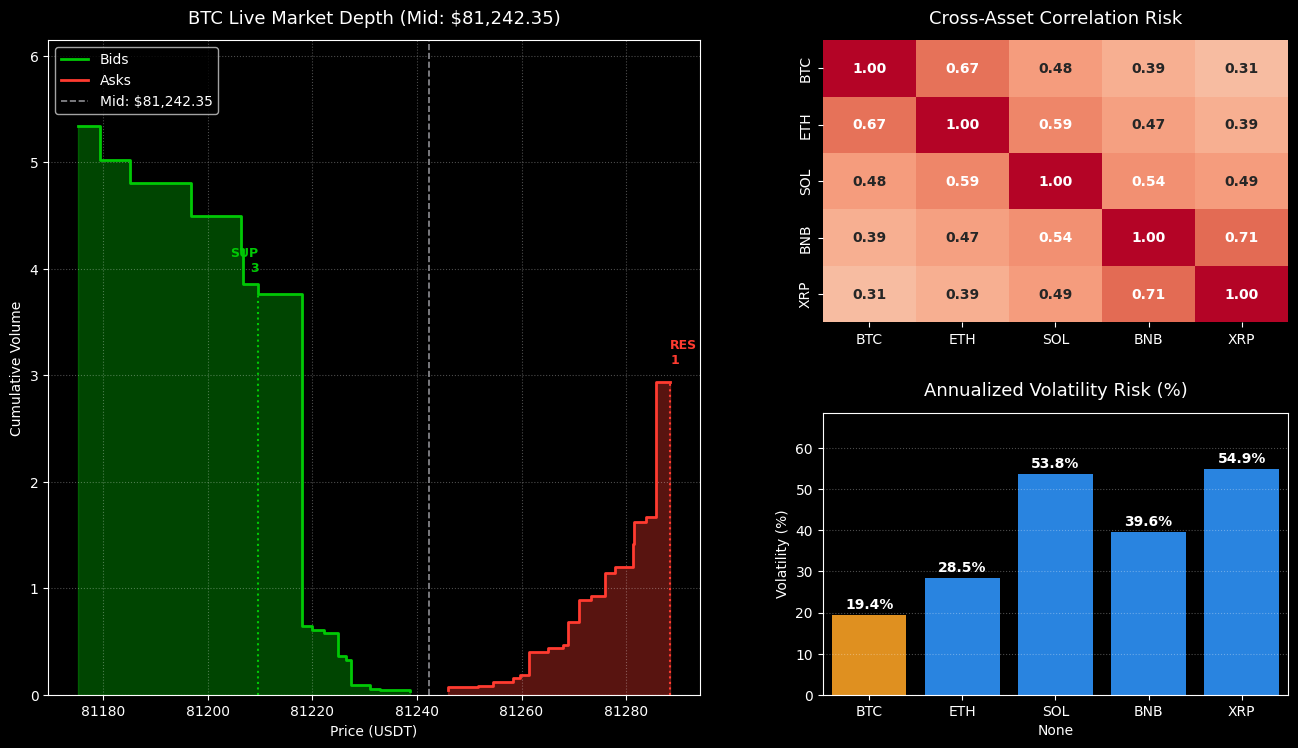

/tmp/ipykernel_10874/2225256023.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


⚠️ Sequence gap detected. Re-syncing...
✅ REST Snapshot applied. Book synced at ID 3316224342
⚠️ Sequence gap detected. Re-syncing...


/tmp/ipykernel_10874/2225256023.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ REST Snapshot applied. Book synced at ID 3316224346
⚠️ Sequence gap detected. Re-syncing...


/tmp/ipykernel_10874/2225256023.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


...

✅ REST Snapshot applied. Book synced at ID 3316224554
⚠️ Sequence gap detected. Re-syncing...
✅ REST Snapshot applied. Book synced at ID 3316224558
⚠️ Sequence gap detected. Re-syncing...


/tmp/ipykernel_10874/2225256023.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ REST Snapshot applied. Book synced at ID 3316224559


/tmp/ipykernel_10874/2225256023.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


⚠️ Sequence gap detected. Re-syncing...

🛑 Live stream safely terminated.
✅ REST Snapshot applied. Book synced at ID 3316224561


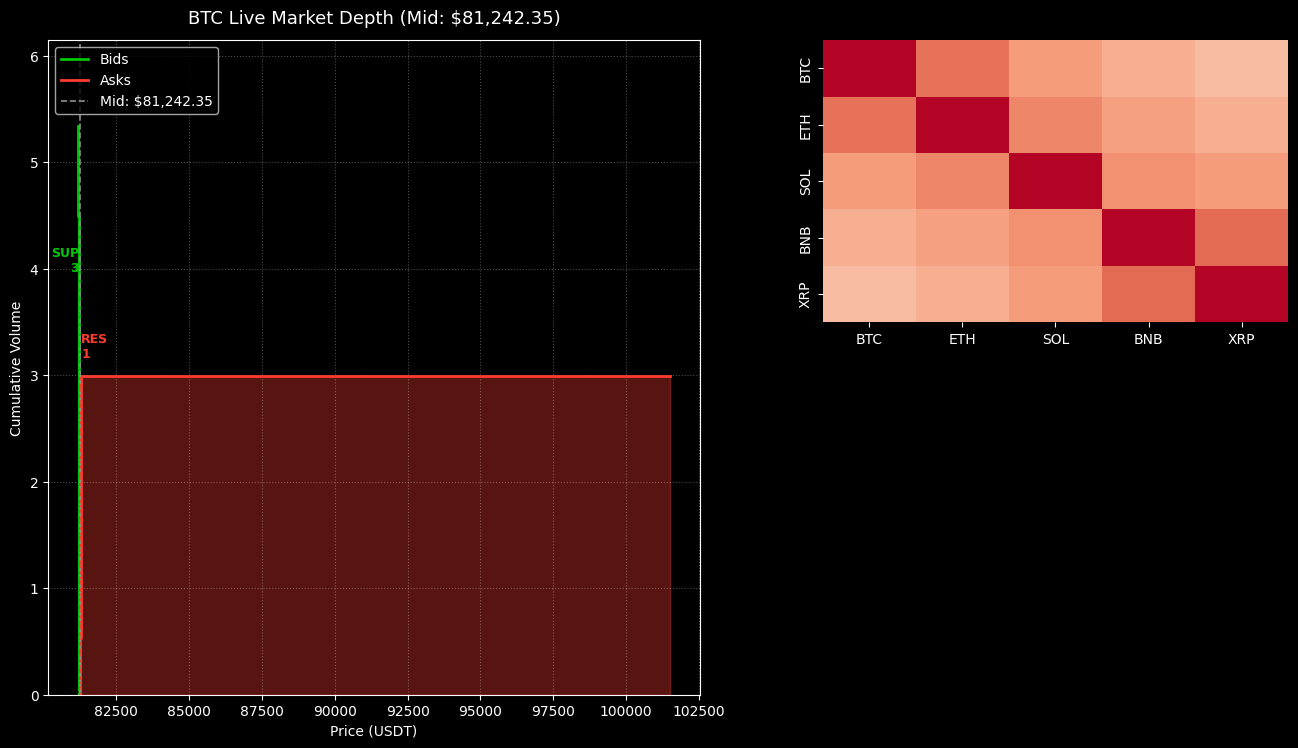

In [ ]:
import time
from IPython.display import display

target_asset = 'BTC'
refresh_rate_seconds = 0.1

print(f"⏳ Opening background internet connection for {target_asset}...")

# Timeout safety net
timeout_seconds = 15
start_wait = time.time()

# 1. Synchronization Lock
while True:
    bids, asks = get_live_orderbook(portfolio_pairs[target_asset])
    if not bids.empty:
        print("✅ Orderbook buffer populated!")
        break
    if time.time() - start_wait > timeout_seconds:
        print("❌ TIMEOUT: Could not establish WebSocket. Exchange server may be blocking the Colab IP.")
        break
    time.sleep(0.5)

# 2. Only launch if data actually exists
if not bids.empty:
    print(f"🔴 LIVE STREAM ACTIVE | Dashboard refreshing every {refresh_rate_seconds}s (Press Stop [■] to end)")

    # Generate the very first frame
    current_fig = build_matplotlib_dashboard(target_asset)

    # Lock it into a specific UI window and grab the "handle"
    chart_display = display(current_fig, display_id=True)

    try:
        while True:
            # Pause to respect the refresh rate
            time.sleep(refresh_rate_seconds)

            # Generate the next frame silently in the background
            new_fig = build_matplotlib_dashboard(target_asset)

            # Instantly overwrite the locked UI window
            chart_display.update(new_fig)

    except KeyboardInterrupt:
        print("\n🛑 Live stream safely terminated.")